# 下一课：FrozenLake 冰湖环境入门

这一课我们进入强化学习里另一个非常经典的环境：`FrozenLake`。

和前面的 `LineWorld`、`Cliff Walking` 相比，它更像标准教材和 Gym 里的示例环境。

这节课你会学到：
- 什么是稀疏奖励 `sparse reward`
- 为什么智能体在早期训练时看起来像什么都没学到
- Q-learning 在二维网格环境里是怎么慢慢学出策略的


## 1. 环境介绍

我们用一个 `4 x 4` 的冰湖地图：

- `S`：起点
- `F`：安全冰面
- `H`：洞，掉进去就结束
- `G`：目标

地图如下：

`S F F F`

`F H F H`

`F F F H`

`H F F G`

奖励规则：
- 到达 `G`，奖励 `1`
- 掉进 `H`，奖励 `0`
- 其他地方，奖励 `0`

这就是典型的稀疏奖励环境，因为大多数时候你都拿不到任何反馈。


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
random.seed(42)
np.random.seed(42)


In [4]:
class FrozenLakeEnv:
    def __init__(self):
        self.grid = [
            ['S', 'F', 'F', 'F'],
            ['F', 'H', 'F', 'H'],
            ['F', 'F', 'F', 'H'],
            ['H', 'F', 'F', 'G']
        ]
        self.rows = len(self.grid)
        self.cols = len(self.grid[0])
        self.n_states = self.rows * self.cols
        self.n_actions = 4  # 0=left, 1=down, 2=right, 3=up
        self.start = (0, 0)
        self.goal = (3, 3)
        self.reset()

    def to_state(self, pos):
        return pos[0] * self.cols + pos[1]

    def from_state(self, state):
        return divmod(state, self.cols)

    def reset(self):
        self.agent = self.start
        return self.to_state(self.agent)

    def step(self, action):
        r, c = self.agent

        if action == 0:
            c = max(0, c - 1)
        elif action == 1:
            r = min(self.rows - 1, r + 1)
        elif action == 2:
            c = min(self.cols - 1, c + 1)
        else:
            r = max(0, r - 1)

        self.agent = (r, c)
        cell = self.grid[r][c]

        if cell == 'H':
            return self.to_state(self.agent), 0, True
        if cell == 'G':
            return self.to_state(self.agent), 1, True
        return self.to_state(self.agent), 0, False

    def render_policy(self, policy):
        action_map = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}
        rows = []
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                cell = self.grid[r][c]
                if cell in ('S', 'H', 'G'):
                    row.append(cell)
                else:
                    state = self.to_state((r, c))
                    row.append(action_map[int(policy[state])])
            rows.append(row)
        return rows


## 2. 为什么这个环境更难

和前面的例子相比，`FrozenLake` 更难学，原因很简单：

- 大部分时候奖励都是 `0`
- 一不小心会掉进洞里直接结束
- 只有走对整条路线，最后到终点时才拿到 `1`

所以训练前期很可能会出现：
- reward 曲线几乎贴着 0
- Q 表大部分位置都接近 0

这不一定是代码错了，而是稀疏奖励环境本来就更难。


In [5]:
def choose_action(state, q_table, epsilon):
    if random.random() < epsilon:
        return random.randint(0, q_table.shape[1] - 1)

    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(random.choice(best_actions))


In [6]:
env = FrozenLakeEnv()
q_table = np.zeros((env.n_states, env.n_actions))

alpha = 0.1
gamma = 0.99
epsilon = 0.3
episodes = 2000
max_steps = 100

episode_rewards = []
success_history = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for _step in range(max_steps):
        action = choose_action(state, q_table, epsilon)
        next_state, reward, done = env.step(action)

        old_value = q_table[state, action]
        next_best = 0 if done else np.max(q_table[next_state])
        target = reward + gamma * next_best
        q_table[state, action] = old_value + alpha * (target - old_value)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)
    success_history.append(1 if total_reward > 0 else 0)
    epsilon = max(0.02, epsilon * 0.999)

print('训练完成。')
print('最终 Q 表：')
print(q_table)
print('最后 100 轮成功率:', round(float(np.mean(success_history[-100:])), 3))


训练完成。
最终 Q 表：
[[0.937 0.951 0.912 0.939]
 [0.938 0.    0.067 0.141]
 [0.356 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.948 0.961 0.    0.932]
 [0.    0.    0.    0.   ]
 [0.    0.243 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.956 0.    0.97  0.942]
 [0.954 0.98  0.976 0.   ]
 [0.227 0.99  0.    0.028]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.973 0.99  0.969]
 [0.978 0.985 1.    0.971]
 [0.    0.    0.    0.   ]]
最后 100 轮成功率: 0.95


In [7]:
policy = np.argmax(q_table, axis=1)
policy_grid = env.render_policy(policy)

print('学到的策略：')
for row in policy_grid:
    print(' '.join(row))


学到的策略：
S L L L
D H D H
R D D H
H R R G


C:\Users\80740\AppData\Local\Temp\ipykernel_30980\3987208356.py:17: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_30980\3987208356.py:17: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_30980\3987208356.py:17: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_30980\3987208356.py:17: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_30980\3987208356.py:17: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\80740\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEO

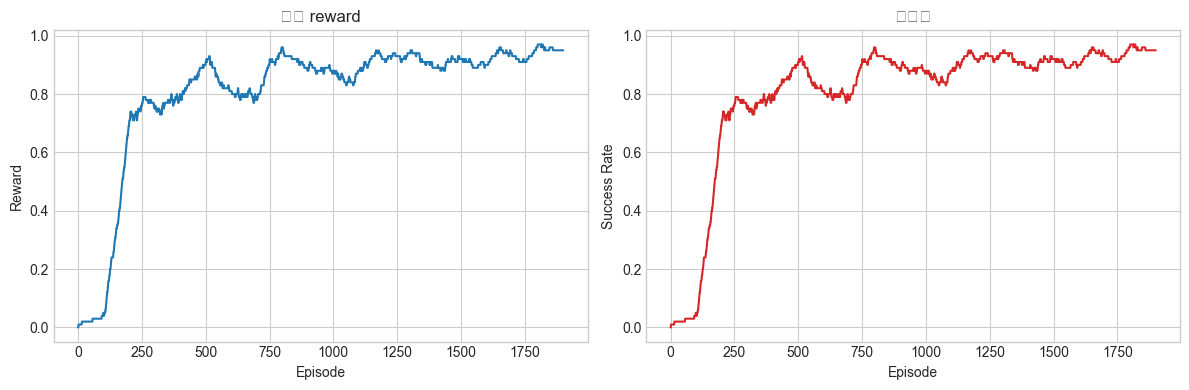

In [8]:
window = 100
smoothed_reward = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')
smoothed_success = np.convolve(success_history, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(smoothed_reward, color='#1f77b4')
axes[0].set_title('平均 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

axes[1].plot(smoothed_success, color='#d62728')
axes[1].set_title('成功率')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate')

plt.tight_layout()
plt.show()


## 3. 怎么看结果

如果训练正常，你通常会看到：

- 前期成功率很低，几乎总是 0
- 后期成功率开始慢慢升高
- 学到的策略会绕开洞，朝目标走

这就是稀疏奖励环境的典型特征：

不是每一步都有反馈，而是要很久以后才知道之前那串动作到底对不对。


## 4. 这一课记住什么

1. `FrozenLake` 是典型的稀疏奖励环境。
2. 在这种环境里，训练初期 reward 长时间接近 0 很正常。
3. Q-learning 依然能学，但需要更多 episode 和更多探索。

最适合的下一课是：
- 给 `FrozenLake` 加滑动随机性
- 正式进入 `Gymnasium` 版本的 FrozenLake
- 从表格法过渡到 `DQN` 的第一课
